In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

from scipy.sparse import vstack, load_npz
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as skm
import sklearn.utils as sku

import torch as pt
import torch.nn as nn
import torch.optim as optim

from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset, DataLoader

import optuna as opt

import Basic_functions as bf

from torchao.sparsity.training import (
    SemiSparseLinear,
    SemiSparseActivationLinear,
    swap_linear_with_semi_sparse_linear,
    swap_semi_sparse_linear_with_linear,
)

# Optional imports
# from torch.nn import L1Loss
# from scipy.special import expit

W0609 08:08:59.901000 81107 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
import numpy as np
from scipy import sparse
from scipy.sparse import load_npz, hstack
from sklearn.preprocessing import StandardScaler
import sklearn.utils as sku

# --------------------------------------------------------
# PATHS
# --------------------------------------------------------

DATA_FILE = "/Users/psf728/Desktop/data_nltk.npz"
LABEL_FILE = "Data_files/labels_nltk.txt"
SORT_FILE = "txt_files/regression_nltk_sort_idx.txt"

# --------------------------------------------------------
# LABEL COLUMN STRUCTURE
# --------------------------------------------------------

LIX_COL = 0
TOPIC_COL = 1
ARTICLE_COL = 2
DATE_COL = 3

# --------------------------------------------------------
# LOAD DATA
# --------------------------------------------------------

data_articles_all = load_npz(DATA_FILE)

labels_articles_all = np.genfromtxt(
    LABEL_FILE,
    delimiter=";",
    dtype=str,
    skip_header=1
)

sort_idx = np.genfromtxt(
    SORT_FILE,
    delimiter="\n",
    dtype=int
)

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

print("Initial data shape:", data_articles_all.shape)
print("Initial number of labels:", labels_articles_all.shape[0])

# --------------------------------------------------------
# KEEP ONLY ARTICLES
# --------------------------------------------------------

article_indicator = labels_articles_all[:, ARTICLE_COL].astype(int)
article_mask = article_indicator == 1

print("\nArticles kept:", article_mask.sum())
print("Speeches removed:", (~article_mask).sum())

data_articles_all = data_articles_all[article_mask]
labels_articles_all = labels_articles_all[article_mask]

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

# --------------------------------------------------------
# KEEP ONLY TOP X MOST FREQUENT ARTICLE TOPICS
# --------------------------------------------------------

top_x = 10

topics = labels_articles_all[:, TOPIC_COL]

unique_topics, topic_counts = np.unique(
    topics,
    return_counts=True
)

sorted_indices = np.argsort(topic_counts)[::-1]
valid_topics = unique_topics[sorted_indices[:top_x]]

keep_mask = np.isin(topics, valid_topics)

print("\nOriginal number of articles after removing speeches:", data_articles_all.shape[0])
print("Filtered number of articles:", keep_mask.sum())
print("Removed articles outside top topics:", data_articles_all.shape[0] - keep_mask.sum())

print("\nTop topics kept:")
for topic in valid_topics:
    count = np.sum(topics == topic)
    print(f"{topic}: {count}")

data_articles_all = data_articles_all[keep_mask]
labels_articles_all = labels_articles_all[keep_mask]

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

# --------------------------------------------------------
# ADD LIX SCORE AS FIRST COLUMN
# --------------------------------------------------------

lix_scores = labels_articles_all[:, LIX_COL].astype(np.float32)

lix_column = sparse.csr_matrix(
    lix_scores.reshape(-1, 1)
)

data_articles_all = hstack(
    [lix_column, data_articles_all],
    format="csr"
)

print("Shape after adding LIX:", data_articles_all.shape)

# --------------------------------------------------------
# APPLY COLUMN SORTING / FEATURE COMBING
# --------------------------------------------------------

print("\nData columns before sorting:", data_articles_all.shape[1])
print("Smallest sort index:", sort_idx.min())
print("Largest sort index:", sort_idx.max())

sort_idx = sort_idx[
    sort_idx < data_articles_all.shape[1]
]

print("Number of valid sort indices:", len(sort_idx))

data_articles_all = data_articles_all[:, sort_idx][:, :20000]

print("Shape after combing:", data_articles_all.shape)

# --------------------------------------------------------
# SCALE FEATURES
# --------------------------------------------------------

scaler = StandardScaler(with_mean=False)

data_articles_all = scaler.fit_transform(
    data_articles_all
)

# --------------------------------------------------------
# CREATE REGRESSION LABELS: ARTICLE DATES
# --------------------------------------------------------

y_years = labels_articles_all[:, DATE_COL].astype(np.float32)

print("\nDate label summary after selecting top topics:")
print("Min year:", y_years.min())
print("Max year:", y_years.max())
print("Mean year:", y_years.mean())
print("Number of unique dates:", len(np.unique(y_years)))

print("\nTopic distribution used for regression dataset:")
filtered_topics = labels_articles_all[:, TOPIC_COL]

for topic in valid_topics:
    count = np.sum(filtered_topics == topic)
    print(f"{topic}: {count}")

# --------------------------------------------------------
# SHUFFLE DATA AND DATE LABELS
# --------------------------------------------------------

data_articles_all, y_years = sku.shuffle(
    data_articles_all,
    y_years,
    random_state=5466542
)

# --------------------------------------------------------
# OUTPUT
# --------------------------------------------------------

print("\nFinal data shape:", data_articles_all.shape)
print("Final number of date labels:", y_years.shape[0])

print("\nExample feature row:")
print(data_articles_all[0])

print("\nExample date label:")
print(y_years[0])

Initial data shape: (780044, 64478)
Initial number of labels: 780044

Articles kept: 775291
Speeches removed: 4753

Original number of articles after removing speeches: 775291
Filtered number of articles: 434564
Removed articles outside top topics: 340727

Top topics kept:
Danmark: 128229
Internationalt: 126256
Politik: 34536
Kultur: 30699
Sport: 29083
Fodbold: 24600
Økonomi: 22715
Forbrug: 13565
Film og tv: 13085
Cykling: 11796
Shape after adding LIX: (434564, 64479)

Data columns before sorting: 64479
Smallest sort index: 0
Largest sort index: 64478
Number of valid sort indices: 64479
Shape after combing: (434564, 20000)

Date label summary after selecting top topics:
Min year: 2000.1052
Max year: 2026.4714
Mean year: 2013.8232
Number of unique dates: 9082

Topic distribution used for regression dataset:
Danmark: 128229
Internationalt: 126256
Politik: 34536
Kultur: 30699
Sport: 29083
Fodbold: 24600
Økonomi: 22715
Forbrug: 13565
Film og tv: 13085
Cykling: 11796

Final data shape: (434

In [3]:
#class MyDataset(Dataset):    
    #def __init__(self, X_data, y_data):
        #self.input = X_data
        #self.truth = y_data
        
    #def __getitem__(self, index):
        #return self.input[index], self.truth[index]
        
    #def __len__ (self):
        #return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
#train_data = MyDataset(data_train, data_train_labels)
#val_data = MyDataset(data_val, data_val_labels)

import numpy as np
import pandas as pd
import torch as pt
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------------------
# CREATE REGRESSION TARGET FROM ARTICLE DATE
# --------------------------------------------------------

y_years = labels_articles_all[:, DATE_COL].astype(np.float32)

valid_date_mask = ~np.isnan(y_years)

X_reg = data_articles_all[valid_date_mask]
y_years = y_years[valid_date_mask]

print("Earliest year:", y_years.min())
print("Latest year:", y_years.max())
print("Number of articles:", X_reg.shape[0])

y_scaler = StandardScaler()

y_scaled = y_scaler.fit_transform(
    y_years.reshape(-1, 1)
).astype(np.float32)

# --------------------------------------------------------
# SPLIT REGRESSION DATA INTO TRAIN, VAL, TEST SETS
# --------------------------------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X_reg,
    y_scaled,
    test_size=0.2,
    random_state=42
)


print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
#print("Test size:", X_test.shape[0])

class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
train_data_reg = MyDataset(X_train, y_train)
val_data_reg = MyDataset(X_val, y_val)

Earliest year: 2000.1052
Latest year: 2026.4714
Number of articles: 434564
Train size: 347651
Validation size: 86913


In [4]:
# Training loop:
def Train(model, optimizer, loss_function, train_loader, validation_loader, device, epochs):
    validation_loss = []
    training_loss   = []
    model.train()
    for e in range(0, epochs):
        epoch_loss = 0
        n_minibatches = 0
        for input_train_batch, truth_train_batch in train_loader:
            input_train_batch, truth_train_batch = input_train_batch.to(device), truth_train_batch.to(device)
            optimizer.zero_grad()
            prediction = model(input_train_batch)  # This asks our model to produce predictions on the training batch            
            loss = loss_function(prediction, truth_train_batch.long())  # This calculates the loss
            loss.backward()                                             # This initiates the backpropagation
            optimizer.step()
            epoch_loss += loss.item()
            n_minibatches += 1
        
        # Now that the model have trained 1 epoch, we evaluate the model on the validation set:
        valid_loss = Validate(model, validation_loader, device, loss_function)
        validation_loss.append(valid_loss)
        training_loss.append(epoch_loss/n_minibatches)
        print('EPOCH: %s | training loss: %s  | validation loss: %s'%(e+1,round(epoch_loss/n_minibatches,3), round(valid_loss, 3)))
    return training_loss, validation_loss


def Validate(model, validation_loader, device, loss_function):
    model.eval()
    n_batches  = 0
    validation_loss = 0
    with pt.no_grad():
        for input_valid_batch, truth_valid_batch in validation_loader:
            input_valid_batch, truth_valid_batch = input_valid_batch.to(device), truth_valid_batch.to(device)
            prediction = model(input_valid_batch)
            loss = loss_function(prediction, truth_valid_batch.long())
            validation_loss += loss.item()
            n_batches += 1
    validation_loss = validation_loss/n_batches
    return validation_loss


def Predict(model, prediction_loader, device):
    model.eval()
    predictions = []
    print('PREDICTING!')
    with pt.no_grad():
        for input_pred_batch, _ in prediction_loader:
            input_pred_batch = input_pred_batch.to(device)
            prediction = model(input_pred_batch)
            predictions.extend(prediction.numpy())
    print('Done Predicting!')
    return predictions
                
class MeanRelativeAbsoluteDeviationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps
                
    def forward(self, prediction, target):
        prediction = prediction.view_as(target)
        relative_absolute_error = pt.abs(prediction - target) / (pt.abs(target) + self.eps)
        return pt.mean(relative_absolute_error)

In [5]:
def sparse_collate(batch):
    xs, ys = zip(*batch)

    first = xs[0]
    n_features = first.shape[-1]

    batch_rows = []
    batch_cols = []
    batch_vals = []

    for i, x in enumerate(xs):
        x = x.tocoo()
        batch_rows.append(np.full_like(x.col, i, dtype=np.int64))
        batch_cols.append(x.col.astype(np.int64))
        batch_vals.append(x.data.astype(np.float32))

    indices = pt.tensor(
        np.vstack([np.concatenate(batch_rows), np.concatenate(batch_cols)]),
        dtype=pt.long
    )
    values = pt.tensor(np.concatenate(batch_vals), dtype=pt.float32)

    X = pt.sparse_coo_tensor(indices, values, size=(len(xs), n_features)).coalesce()
    y = pt.tensor(np.asarray(ys), dtype=pt.long)
    return X, y

In [6]:
n = 3

def objective(trial):

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-3,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [ 32, 64, 128, 256 ]
    )

    Layer1 = trial.suggest_int("Layer1", 128*n, 512*n)
    Layer2 = trial.suggest_int("Layer2", 64*n, 256*n)
    Layer3 = trial.suggest_int("Layer3", 16*n, 64*n)

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.1,
        0.5
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-3,
        log=True
    )

    n_epochs = 3

    input_dim = X_train.shape[1]

    class OptRegressionModel(nn.Module):

        def __init__(self):
            super(OptRegressionModel, self).__init__()

            self.input_layer = nn.Linear(input_dim, Layer1)
            self.hidden_layer1 = nn.Linear(Layer1, Layer2)
            self.hidden_layer2 = nn.Linear(Layer2, Layer3)
            self.output_layer = nn.Linear(Layer3, 1)

            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(dropout_rate)

        def forward(self, inputs):

            x = self.input_layer(inputs)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer1(x)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer2(x)
            x = self.relu(x)

            x = self.output_layer(x)

            return x

    device = pt.device(
        "cuda" if pt.cuda.is_available() else "cpu"
    )

    model_opt = OptRegressionModel().to(device)

    loss_function = nn.MSELoss()

    optimizer = optim.Adam(
        model_opt.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    train_loader = DataLoader(
        dataset=train_data_reg,
        batch_size=batch_size,
        shuffle=True
    )

    validation_loader = DataLoader(
        dataset=val_data_reg,
        batch_size=batch_size,
        shuffle=False
    )

    best_validation_loss = float("inf")

    epoch_bar = tqdm(
        range(n_epochs),
        desc=f"Trial {trial.number}",
        leave=False,
        unit="epoch"
    )

    for epoch in epoch_bar:

        model_opt.train()
        epoch_training_loss = 0

        for input_batch, truth_batch in train_loader:

            input_batch = input_batch.to(device)
            truth_batch = truth_batch.to(device)

            optimizer.zero_grad()

            predictions = model_opt(input_batch).squeeze()

            loss = loss_function(
                predictions,
                truth_batch
            )

            loss.backward()
            optimizer.step()

            epoch_training_loss += loss.item()

        epoch_training_loss /= len(train_loader)

        model_opt.eval()
        epoch_validation_loss = 0

        with pt.no_grad():

            for input_batch, truth_batch in validation_loader:

                input_batch = input_batch.to(device)
                truth_batch = truth_batch.to(device)

                predictions = model_opt(input_batch).squeeze()

                loss = loss_function(
                    predictions,
                    truth_batch
                )

                epoch_validation_loss += loss.item()

        epoch_validation_loss /= len(validation_loader)

        best_validation_loss = min(
            best_validation_loss,
            epoch_validation_loss
        )

        epoch_bar.set_postfix(
            train_loss=f"{epoch_training_loss:.4f}",
            val_loss=f"{epoch_validation_loss:.4f}",
            best=f"{best_validation_loss:.4f}"
        )

        trial.report(epoch_validation_loss, epoch)

        if trial.should_prune():
            raise opt.exceptions.TrialPruned()

    return best_validation_loss

In [7]:
def progress_callback(study, trial):

    optuna_bar.update(1)

    if study.best_trial is not None:
        optuna_bar.set_postfix(
            best_loss=f"{study.best_value:.4f}",
            best_trial=study.best_trial.number
        )

# HP optimization

In [8]:
class SparseRegressionDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx].toarray().squeeze()
        y = self.y[idx]

        return (
            pt.tensor(x, dtype=pt.float32),
            pt.tensor(y, dtype=pt.float32)
        )

train_data_reg = SparseRegressionDataset(X_train, y_train)
val_data_reg = SparseRegressionDataset(X_val, y_val)
#test_data_reg = SparseRegressionDataset(X_test, y_test)

In [9]:
from tqdm.auto import tqdm

n_trials = 5

pruner = opt.pruners.MedianPruner(
    n_startup_trials=2,
    n_warmup_steps=1
)

study = opt.create_study(
    direction="minimize",
    pruner=pruner
)

optuna_bar = tqdm(
    total=n_trials,
    desc="Optuna Trials",
    unit="trial"
)

device = pt.device(
    "cuda" if pt.cuda.is_available() else "cpu"
)

print(device)

study.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[progress_callback]
)

optuna_bar.close()

print("Best trial:")
print(study.best_trial)

print("Best parameters:")
print(study.best_trial.params)

best_params = study.best_trial.params

learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]
dropout_rate = best_params["dropout_rate"]
weight_decay = best_params["weight_decay"]

Layer1 = best_params["Layer1"]
Layer2 = best_params["Layer2"]
Layer3 = best_params["Layer3"]

[I 2026-06-09 08:09:07,172] A new study created in memory with name: no-name-0dfe4409-944b-47b1-9044-d1372a25cafc


Optuna Trials:   0%|          | 0/5 [00:00<?, ?trial/s]

cpu


Trial 0:   0%|          | 0/3 [00:00<?, ?epoch/s]

/opt/anaconda3/envs/app-ml/lib/python3.12/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([128, 1])) that is different to the input size (torch.Size([128])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/anaconda3/envs/app-ml/lib/python3.12/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([3, 1])) that is different to the input size (torch.Size([3])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/anaconda3/envs/app-ml/lib/python3.12/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they h

...

Trial 3:   0%|          | 0/3 [00:00<?, ?epoch/s]

[I 2026-06-09 08:37:41,352] Trial 3 finished with value: 0.9947041543091044 and parameters: {'learning_rate': 1.094197224266012e-05, 'batch_size': 256, 'Layer1': 935, 'Layer2': 712, 'Layer3': 187, 'dropout_rate': 0.13140677237107218, 'weight_decay': 5.333238599341521e-05}. Best is trial 1 with value: 0.9946682889671886.


Trial 4:   0%|          | 0/3 [00:00<?, ?epoch/s]

/opt/anaconda3/envs/app-ml/lib/python3.12/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
[I 2026-06-09 08:52:27,425] Trial 4 pruned. 


Best trial:
FrozenTrial(number=1, state=<TrialState.COMPLETE: 1>, values=[0.9946682889671886], datetime_start=datetime.datetime(2026, 6, 9, 8, 19, 47, 618097), datetime_complete=datetime.datetime(2026, 6, 9, 8, 25, 16, 966105), params={'learning_rate': 0.00016819570101347554, 'batch_size': 256, 'Layer1': 890, 'Layer2': 548, 'Layer3': 164, 'dropout_rate': 0.14448601572522102, 'weight_decay': 4.852658105400232e-06}, user_attrs={}, system_attrs={}, intermediate_values={0: 0.9946803042117287, 1: 0.994677847623825, 2: 0.9946682889671886}, distributions={'learning_rate': FloatDistribution(high=0.001, log=True, low=1e-05, step=None), 'batch_size': CategoricalDistribution(choices=(32, 64, 128, 256)), 'Layer1': IntDistribution(high=1536, log=False, low=384, step=1), 'Layer2': IntDistribution(high=768, log=False, low=192, step=1), 'Layer3': IntDistribution(high=192, log=False, low=48, step=1), 'dropout_rate': FloatDistribution(high=0.5, log=False, low=0.1, step=None), 'weight_decay': FloatDistri

# Split data before training

In [10]:
#class MyDataset(Dataset):    
    #def __init__(self, X_data, y_data):
        #self.input = X_data
        #self.truth = y_data
        
    #def __getitem__(self, index):
        #return self.input[index], self.truth[index]
        
    #def __len__ (self):
        #return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
#train_data = MyDataset(data_train, data_train_labels)
#val_data = MyDataset(data_val, data_val_labels)

import numpy as np
import pandas as pd
import torch as pt
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------------------
# CREATE REGRESSION TARGET FROM ARTICLE DATE
# --------------------------------------------------------

y_years = labels_articles_all[:, DATE_COL].astype(np.float32)

valid_date_mask = ~np.isnan(y_years)

X_reg = data_articles_all[valid_date_mask]
y_years = y_years[valid_date_mask]

print("Earliest year:", y_years.min())
print("Latest year:", y_years.max())
print("Number of articles:", X_reg.shape[0])

y_scaler = StandardScaler()

y_scaled = y_scaler.fit_transform(
    y_years.reshape(-1, 1)
).astype(np.float32)

# --------------------------------------------------------
# SPLIT REGRESSION DATA INTO TRAIN, VAL, TEST SETS
# --------------------------------------------------------

X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X_reg,
    y_scaled,
    test_size=0.1,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp,
    y_train_temp,
    test_size=0.20,
    random_state=42
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
train_data_reg = MyDataset(X_train, y_train)
val_data_reg = MyDataset(X_val, y_val)

class SparseRegressionDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx].toarray().squeeze()
        y = self.y[idx]

        return (
            pt.tensor(x, dtype=pt.float32),
            pt.tensor(y, dtype=pt.float32)
        )

train_data_reg = SparseRegressionDataset(X_train, y_train)
val_data_reg = SparseRegressionDataset(X_val, y_val)
test_data_reg = SparseRegressionDataset(X_test, y_test)

Earliest year: 2000.1052
Latest year: 2026.4714
Number of articles: 434564
Train size: 312885
Validation size: 78222
Test size: 43457


# Training

In [ ]:
import torch as pt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

input_dim = X_train.shape[1]

learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]
weight_decay = best_params["weight_decay"]

Layer1 = best_params["Layer1"]
Layer2 = best_params["Layer2"]
Layer3 = best_params["Layer3"]

# Lower dropout for regression
dropout_rate = min(best_params["dropout_rate"], 0.15)

class DateRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, Layer1),
            nn.BatchNorm1d(Layer1),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(Layer1, Layer2),
            nn.BatchNorm1d(Layer2),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(Layer2, Layer3),
            nn.GELU(),

            nn.Linear(Layer3, 1)
        )

    def forward(self, x):
        return self.network(x)

device = pt.device("cuda" if pt.cuda.is_available() else "cpu")
model = DateRegressionModel().to(device)

optimizer = optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

loss_function = nn.SmoothL1Loss(beta=0.5)

train_loader = DataLoader(train_data_reg, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(val_data_reg, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data_reg, batch_size=batch_size, shuffle=False)

n_epochs = 5
patience = 2

best_val_loss = np.inf
best_state = None
bad_epochs = 0

training_loss = []
validation_loss = []

from tqdm.auto import tqdm

for epoch in tqdm(range(n_epochs), desc="Epochs", position=0):

    # -------------------------
    # TRAIN
    # -------------------------

    model.train()
    train_loss = 0

    train_bar = tqdm(
        train_loader,
        desc=f"Train {epoch+1}/{n_epochs}",
        leave=False,
        position=1
    )

    for xb, yb in train_bar:

        xb = xb.to(device)
        yb = yb.to(device).view(-1, 1)

        optimizer.zero_grad()

        pred = model(xb)

        loss = loss_function(pred, yb)

        loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        train_loss += loss.item()

        train_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss /= len(train_loader)

    # -------------------------
    # VALIDATION
    # -------------------------

    model.eval()
    val_loss = 0

    val_bar = tqdm(
        validation_loader,
        desc=f"Valid {epoch+1}/{n_epochs}",
        leave=False,
        position=1
    )

    with pt.no_grad():

        for xb, yb in val_bar:

            xb = xb.to(device)
            yb = yb.to(device).view(-1, 1)

            pred = model(xb)

            loss = loss_function(pred, yb)

            val_loss += loss.item()

            val_bar.set_postfix(
                loss=f"{loss.item():.4f}"
            )

    val_loss /= len(validation_loader)

    training_loss.append(train_loss)
    validation_loss.append(val_loss)

    print(
        f"Epoch {epoch+1:03d} | "
        f"train loss {train_loss:.4f} | "
        f"val loss {val_loss:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
        bad_epochs = 0
    else:
        bad_epochs += 1

    if bad_epochs >= patience:
        print("Early stopping")
        break

Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Train 1/5:   0%|          | 0/1223 [00:00<?, ?it/s]

In [ ]:
model.eval()
test_predictions_scaled = []

with pt.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        test_predictions_scaled.append(pred)

test_predictions_scaled = np.vstack(test_predictions_scaled)

true_test_years = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
predicted_test_years = y_scaler.inverse_transform(test_predictions_scaled).ravel()

mae = mean_absolute_error(true_test_years, predicted_test_years)
rmse = np.sqrt(mean_squared_error(true_test_years, predicted_test_years))
r2 = r2_score(true_test_years, predicted_test_years)

print(f"MAE  : {mae:.3f} years")
print(f"RMSE : {rmse:.3f} years")
print(f"R²   : {r2:.3f}")

MAE  : 5.791 years
RMSE : 7.055 years
R²   : -0.310


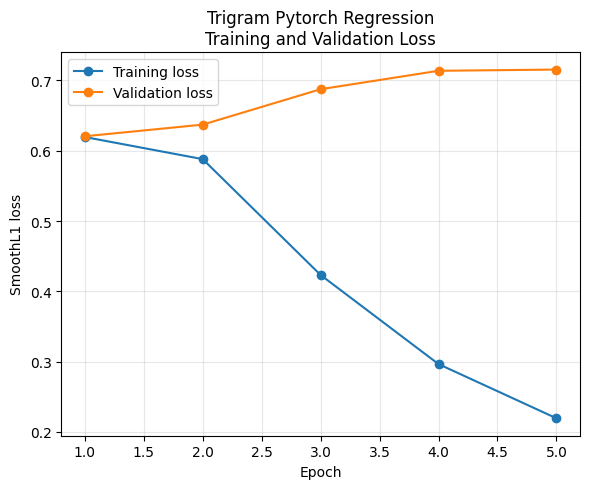

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, len(training_loss) + 1)

eps = 1e-12

log_train_final = np.log(training_loss[-1] + eps)
log_val_final = np.log(validation_loss[-1] + eps)
log_val_best = np.log(np.min(validation_loss) + eps)

plt.figure(figsize=(6, 5))

plt.plot(
    epochs,
    training_loss,
    marker="o",
    label="Training loss"
)

plt.plot(
    epochs,
    validation_loss,
    marker="o",
    label="Validation loss"
)



plt.xlabel("Epoch")
plt.ylabel("SmoothL1 loss")
plt.title("Trigram Pytorch Regression\nTraining and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
model.eval()
test_predictions_scaled = []

with pt.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        test_predictions_scaled.append(pred)

test_predictions_scaled = np.vstack(test_predictions_scaled)

true_test_years = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
predicted_test_years = y_scaler.inverse_transform(test_predictions_scaled).ravel()

mae = mean_absolute_error(true_test_years, predicted_test_years)
rmse = np.sqrt(mean_squared_error(true_test_years, predicted_test_years))
r2 = r2_score(true_test_years, predicted_test_years)

print(f"MAE  : {mae:.3f} years")
print(f"RMSE : {rmse:.3f} years")
print(f"R²   : {r2:.3f}")

MAE  : 5.791 years
RMSE : 7.055 years
R²   : -0.310


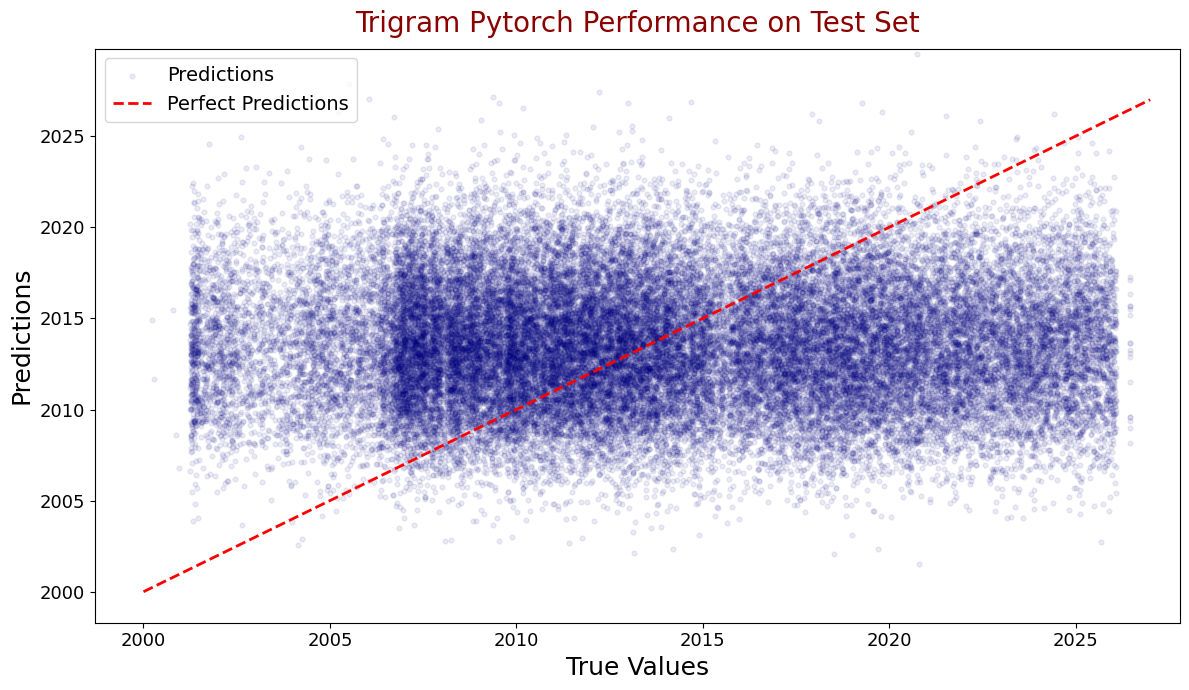

R²  = -0.309716
MSE = 49.774120


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(true_test_years, predicted_test_years)
mse = mean_squared_error(true_test_years, predicted_test_years)

year_min = 2000
year_max = 2027

plt.figure(figsize=(12, 7))

plt.scatter(
    true_test_years,
    predicted_test_years,
    s=12,
    alpha=0.08,
    color="navy",
    label="Predictions"
)

plt.plot(
    [year_min, year_max],
    [year_min, year_max],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Predictions"
)

plt.xlim(1998.7, 2027.8)
plt.ylim(1998.3, 2029.8)

plt.xlabel("True Values", fontsize=18)
plt.ylabel("Predictions", fontsize=18)

plt.title(
    "Trigram Pytorch Performance on Test Set",
    fontsize=20,
    color="darkred",
    pad=12
)

plt.legend(fontsize=14, loc="upper left")
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.grid(False)
plt.tight_layout()

# Save figure before showing it
plt.savefig(
    "Regression_trigram_pytorch_test_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"R²  = {r2:.6f}")
print(f"MSE = {mse:.6f}")

In [ ]:
import numpy as np

possible_X_names = [
    "X", "X_train", "features", "feature_matrix", 
    "X_features", "train_features", "X_tensor"
]

print("========== VARIABLE SHAPES ==========")

for name in possible_X_names:
    if name in globals():
        obj = globals()[name]
        try:
            arr = np.asarray(obj)
            print(f"{name}: type={type(obj)}, shape={arr.shape}, ndim={arr.ndim}, dtype={arr.dtype}")
        except Exception as e:
            print(f"{name}: type={type(obj)}, could not convert to array: {e}")

print("\n========== TARGET SHAPES ==========")

for name in ["y", "y_train", "y_test", "labels", "years"]:
    if name in globals():
        obj = globals()[name]
        try:
            arr = np.asarray(obj)
            print(f"{name}: type={type(obj)}, shape={arr.shape}, ndim={arr.ndim}, dtype={arr.dtype}")
        except Exception as e:
            print(f"{name}: type={type(obj)}, could not convert to array: {e}")

print("\n========== FIRST FEW VALUES ==========")

if "X_train" in globals():
    print("X_train sample:", X_train[:5] if hasattr(X_train, "__getitem__") else X_train)

if "y_train" in globals():
    print("y_train sample:", y_train[:5] if hasattr(y_train, "__getitem__") else y_train)

========== VARIABLE SHAPES ==========
X_train: type=<class 'scipy.sparse._csr.csr_matrix'>, shape=(), ndim=0, dtype=object

========== TARGET SHAPES ==========
y_train: type=<class 'numpy.ndarray'>, shape=(312885, 1), ndim=2, dtype=float32
y_test: type=<class 'numpy.ndarray'>, shape=(43457, 1), ndim=2, dtype=float32

========== FIRST FEW VALUES ==========
X_train sample: <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 209 stored elements and shape (5, 64479)>
  Coords	Values
  (0, 0)	4.5381268363061364
  (0, 35213)	7.357414730047171
  (0, 26395)	1.7272349581436184
  (0, 20122)	19.413711588875113
  (0, 31455)	4.69990233800838
  (0, 49782)	8.856143918601417
  (0, 5687)	3.282236694529925
  (0, 19202)	27.63915229203058
  (0, 49118)	26.90409664418776
  (0, 47710)	41.249847795312036
  (0, 28290)	20.46018074730907
  (0, 26748)	1.9839547565897402
  (0, 54042)	19.162023491081992
  (0, 41234)	10.639293727031172
  (0, 16745)	19.97373100684113
  (0, 23879)	19.16985676449938
  (0, 611